# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ayaahmed571/Flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

### Research question

Can historical content freshness and performance signals help prioritize content pages for human review?

### Decision supported

The analysis supports a decision-support workflow for prioritizing which content pages may deserve review or refresh attention.

The output is intended to rank pages for human review. It is not intended to make automatic content changes or establish causal relationships.

## 2. Data

### Dataset

This work uses the FlyRank ML Internship dataset.

The working content-level dataset contains 30,000 records and 44 columns.

### Data used

The analysis uses content attributes and historical performance signals, including:

- content age
- days since last update
- impressions over the observed 90-day period
- average search position
- CTR
- word count

### Excluded fields

The declining outcome label and fields used to construct it were excluded from the model features.

In particular:

- `is_declining_label` was not used as a feature.
- `trend_direction` was not used as a feature.
- `trend_pct` was not used as a feature.

These fields were excluded because they represent the outcome or information directly related to the outcome.

No client names, URLs, or private search queries are included in the analysis.

In [42]:
import pandas as pd

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

print("Dataset shape:", df.shape)

print("\nRelevant columns:")
print([
    "content_age_days",
    "days_since_last_update",
    "impressions_90d",
    "avg_position",
    "ctr",
    "word_count",
    "trend_direction"
])

Dataset shape: (30000, 44)

Relevant columns:
['content_age_days', 'days_since_last_update', 'impressions_90d', 'avg_position', 'ctr', 'word_count', 'trend_direction']


## 3. Methodology

### Features

The final model uses six features:

- `content_age_days`
- `days_since_last_update`
- `impressions_90d`
- `avg_position`
- `ctr`
- `word_count`

### Label definition

The binary label `is_declining_label` was defined from the observed `trend_direction` field:

- `1` when `trend_direction` was `down`
- `0` otherwise

The label was used only as the prediction target and was not included among the model features.

### Baseline

The Week-4 baseline is a simple rule-based action score based on content staleness and visibility.

The baseline gives higher priority to content that has not been updated recently and still has measurable visibility.

### Model

A Decision Tree classifier was used as the Week-5 model.

The method was selected because it is interpretable and can capture simple non-linear relationships between the content signals and the declining label.

### Validation design

The honest validation used a grouped split by `client_id`.

A `GroupShuffleSplit` with 20% test data and `random_state=42` was used.

The split produced:

- Training rows: 23,837
- Test rows: 6,163
- Clients appearing in both sets: 0

This prevents the same client from appearing in both training and test sets.

### Leakage checks

The final feature set was checked for direct outcome leakage.

Potential leakage columns identified: none.

The following outcome-related fields were confirmed to be outside the final feature set:

- `is_declining_label`
- `trend_direction`
- `trend_pct`

In [43]:
from sklearn.model_selection import GroupShuffleSplit

# Define the target
df["is_declining_label"] = (
    df["trend_direction"] == "down"
).astype(int)

# Final feature set
features = [
    "content_age_days",
    "days_since_last_update",
    "impressions_90d",
    "avg_position",
    "ctr",
    "word_count"
]

X = df[features].copy()
y = df["is_declining_label"]
groups = df["client_id"]

print("Features:")
print(features)

print("\nLabel distribution:")
print(y.value_counts())

# Grouped train/test split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

overlap = (
    set(groups.iloc[train_idx])
    & set(groups.iloc[test_idx])
)

print("Clients in both train and test:", len(overlap))

Features:
['content_age_days', 'days_since_last_update', 'impressions_90d', 'avg_position', 'ctr', 'word_count']

Label distribution:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64

Train shape: (23837, 6)
Test shape: (6163, 6)
Clients in both train and test: 0


In [44]:
leakage_candidates = [
    "is_declining_label",
    "trend_direction",
    "trend_pct"
]

print("Final features:")
print(features)

print("\nPotential leakage columns:")

for col in leakage_candidates:
    if col in features:
        print(col, ": LEAKED")
    else:
        print(col, ": NOT IN FEATURES")

Final features:
['content_age_days', 'days_since_last_update', 'impressions_90d', 'avg_position', 'ctr', 'word_count']

Potential leakage columns:
is_declining_label : NOT IN FEATURES
trend_direction : NOT IN FEATURES
trend_pct : NOT IN FEATURES


## 4. Results (vs baseline)

The Decision Tree was compared with the Week-4 baseline using precision on the same evaluation setup.

| Method | Precision |
|---|---:|
| Week-5 model / before grouped validation | 0.579 |
| Week-4 baseline | 0.509 |
| Decision Tree / grouped validation | 0.547 |

The grouped validation result was lower than the earlier Week-5 result, from 0.579 to 0.547. This indicates that the earlier estimate was somewhat optimistic when evaluated without the grouped-by-client constraint.

The grouped result is therefore treated as the more honest estimate for this analysis.

The model provides a measured improvement over the baseline in this evaluation, but the result is directional and intended for decision-support rather than a production guarantee.

In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score

# Train Decision Tree
model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model precision
model_precision = precision_score(y_test, y_pred)

# Baseline precision from Week 4
baseline_precision = 0.509

# Comparison table
results = pd.DataFrame({
    "Method": [
        "Week-4 Baseline",
        "Decision Tree (Grouped)"
    ],
    "Precision": [
        baseline_precision,
        model_precision
    ]
})

print(results)

                    Method  Precision
0          Week-4 Baseline   0.509000
1  Decision Tree (Grouped)   0.546911


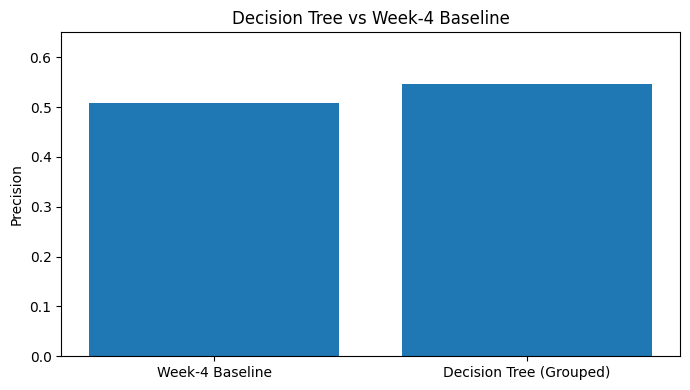

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.bar(
    results["Method"],
    results["Precision"]
)

plt.ylabel("Precision")
plt.title("Decision Tree vs Week-4 Baseline")
plt.ylim(0, 0.65)

plt.tight_layout()

plt.savefig("model_vs_baseline.png", dpi=200, bbox_inches="tight")

plt.show()

The grouped Decision Tree achieved a measured precision of 0.547, compared with 0.509 for the Week-4 baseline on the evaluation data.

This is a measured improvement of approximately 0.038 in precision. The result is directional evidence that the model may provide useful decision-support beyond the simple baseline under this evaluation setup.

## 5. Limitations

This analysis has several limitations.

- The model identifies associations in the observed data; it does not establish causation.
- The grouped validation result is based on one train/test split.
- Precision may change when the content population or data distribution changes.
- The available features do not capture every reason why content performance may decline.
- A recommendation to review or refresh a page does not mean that a refresh will improve its performance.
- The model was evaluated on the available dataset and does not represent a production deployment.
- The output should be treated as decision-support and reviewed by a human before taking action.

## 6. Ranked recommendations

The action playbook prioritizes content for human review using a simple baseline score.

### Priority actions

**Review for refresh**

Pages that are both stale and have observed visibility receive the highest priority.

Reason code:

`STALE_WITH_VISIBILITY`

**Lower priority**

Pages that are stale but have lower observed visibility receive lower priority.

Reason code:

`STALE_LOW_VISIBILITY`

The ranking is intended to help reviewers focus attention on a smaller set of pages first.

The score and reason code are prioritization signals, not final decisions.

In [47]:
import numpy as np

# Recreate the ranked recommendation queue

df["baseline_score"] = (
    (df["days_since_last_update"] >= 180).astype(int) * 2
    + (df["impressions_90d"] >= 500).astype(int)
)

df["reason_code"] = np.where(
    (df["days_since_last_update"] >= 180) &
    (df["impressions_90d"] >= 500),
    "STALE_WITH_VISIBILITY",
    np.where(
        df["days_since_last_update"] >= 180,
        "STALE_LOW_VISIBILITY",
        "NO_ACTION"
    )
)

df["action"] = np.where(
    df["reason_code"] == "STALE_WITH_VISIBILITY",
    "Review for refresh",
    np.where(
        df["reason_code"] == "STALE_LOW_VISIBILITY",
        "Lower priority",
        "No immediate action"
    )
)

queue = df.sort_values(
    ["baseline_score", "impressions_90d"],
    ascending=[False, False]
).copy()

print(queue[
    [
        "content_id",
        "baseline_score",
        "reason_code",
        "action",
        "days_since_last_update",
        "impressions_90d"
    ]
].head(20))

                 content_id  baseline_score            reason_code  \
16751  content_cf56e2e2e282               3  STALE_WITH_VISIBILITY   
16514  content_7368877ea310               3  STALE_WITH_VISIBILITY   
7021   content_1bfaa38ff26c               3  STALE_WITH_VISIBILITY   
21268  content_0a91db491d14               3  STALE_WITH_VISIBILITY   
11489  content_5feee3994adb               3  STALE_WITH_VISIBILITY   
12045  content_c2d929d83eaa               3  STALE_WITH_VISIBILITY   
698    content_b16bd7307b39               3  STALE_WITH_VISIBILITY   
5327   content_fe16a55cd13d               3  STALE_WITH_VISIBILITY   
26810  content_ecb6215e79fd               3  STALE_WITH_VISIBILITY   
20837  content_928af3e22c80               3  STALE_WITH_VISIBILITY   
22872  content_e3ff1b093148               3  STALE_WITH_VISIBILITY   
23215  content_bdbec75c1148               3  STALE_WITH_VISIBILITY   
26840  content_7f116ae1f6f5               3  STALE_WITH_VISIBILITY   
26799  content_77d4d

## 7. Artifacts the paper embeds

The paper includes a small set of reproducible artifacts:

1. Model vs baseline precision comparison.
2. Distribution of recommended actions.
3. Top-ranked action queue for human review.

The figures are generated from the notebook outputs and are intended to support interpretation rather than imply causal effects.

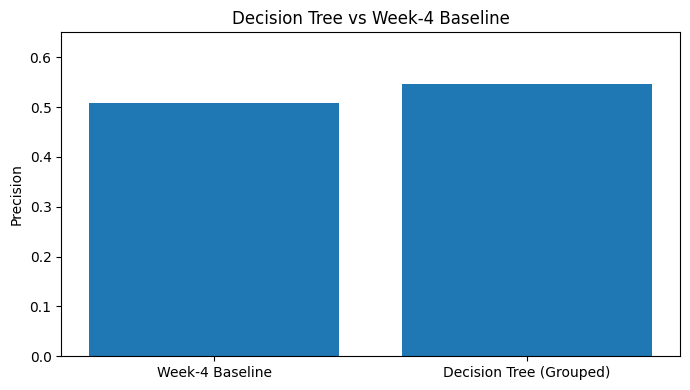

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.bar(
    results["Method"],
    results["Precision"]
)

plt.ylabel("Precision")
plt.title("Decision Tree vs Week-4 Baseline")
plt.ylim(0, 0.65)

plt.tight_layout()
plt.show()

action
No immediate action    29826
Lower priority           157
Review for refresh        17
Name: count, dtype: int64


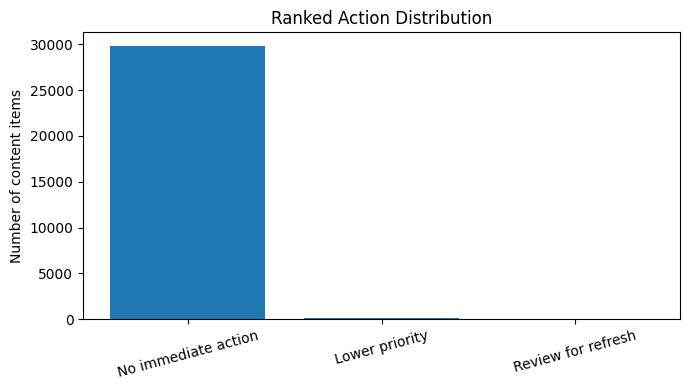

In [49]:
action_counts = queue["action"].value_counts()

print(action_counts)

plt.figure(figsize=(7, 4))

plt.bar(
    action_counts.index,
    action_counts.values
)

plt.ylabel("Number of content items")
plt.title("Ranked Action Distribution")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig("action_distribution.png", dpi=200, bbox_inches="tight")

plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


## ML-12 — 5-Minute Demo Outline

### 0:00–0:45 — Problem
The project addresses the problem of prioritizing content items for refresh or review using observable search-performance signals.

### 0:45–1:30 — Data
The analysis uses the public-safe FlyRank internship warehouse release and focuses on measurable content and search-performance features including content age, update recency, impressions, average search position, CTR, and word count.

### 1:30–2:30 — Method
A transparent baseline prioritization rule was established first. A grouped Decision Tree was then trained using the selected features and evaluated on the same validation split as the baseline.

### 2:30–3:30 — Results
The model and baseline were compared using precision. The results show how the Decision Tree performs relative to the transparent baseline under the defined validation setup.

### 3:30–4:30 — Ranked Actions
The final output converts model signals into a ranked review queue with recommended actions and reason codes, making the result easier to use as a decision-support tool.

### 4:30–5:00 — Takeaway
The analysis provides an evidence-based way to prioritize content for review. The findings are observational and directional: they support prioritization decisions but do not prove that taking a recommended action will cause future performance improvement.

## ML-12 — Social Post

I built an applied ML workflow for content-refresh prioritization using the FlyRank internship dataset.

The project compares a transparent baseline against a grouped Decision Tree, evaluates both using the same validation setup, and turns the results into a ranked action queue with reason codes.

The key takeaway is not "automation solves SEO." It is that observable search signals can support more structured content-prioritization decisions when the model is evaluated honestly against a simple baseline.

The work also highlights the importance of leakage checks, validation design, and careful interpretation when working with observational production data.

## ML-12 — Employer-Facing Summary

This project uses observable search and content signals to build a ranked content-refresh prioritization workflow.

I compared a transparent baseline with a grouped Decision Tree using the same validation setup and evaluated their measured precision.

The resulting action queue demonstrates how an interpretable ML workflow can support practical decision-making while keeping leakage, validation, and causal limitations explicit.